# Real crypto benchmark for online block weighting

This notebook builds a real-data benchmark for the online weighting idea, in the same spirit as the original crypto HMM experiment, but without rerunning expensive chains.

The real-world setting is crypto market stress. Crypto has shifting regimes: sometimes stress is broad-market volatility, sometimes it is downside moves, sometimes it is cross-asset dispersion. That is exactly the kind of situation where a frozen TASS-style weighting rule can get stale and an online weighting model can help.

We use:

- real daily crypto returns from the project data directory;
- the Stan K=2 rolling-standardized Gaussian HMM fit as a stress-state reference;
- 10-day blocks, matching the original block-subsampling flavor;
- a block-level stress-emission gradient proxy as the target;
- four sampling rules: `uniform`, `static_tass`, `online`, and `oracle`.

The benchmark asks a narrow question:

> Given observable block features, which sampling rule gives a lower stochastic-gradient estimator error for stress-state HMM emission gradients?

This is not a full posterior-chain comparison. It is the smaller mechanism-level comparison we want before spending another lifetime running chains.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "crypto_stage1_processed"
STAN_DIR = DATA_DIR / "stan_k2_rollstd_comparison"
OUT_DIR = DATA_DIR / "real_crypto_online_weighting_benchmark"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED = 221
rng = np.random.default_rng(RNG_SEED)

print("project directory:", PROJECT_DIR)
print("data directory:", DATA_DIR)
print("output directory:", OUT_DIR)

project directory: /Users/diego/Stat 221
data directory: /Users/diego/Stat 221/crypto_stage1_processed
output directory: /Users/diego/Stat 221/crypto_stage1_processed/real_crypto_online_weighting_benchmark


## 1. Load real crypto returns and Stan K=2 stress probabilities

The Stan K=2 model already gave us a clean, interpretable two-state crypto HMM. State 1 has much larger posterior volatility than state 0, so we use its smoothed probability as the stress-state soft label.

We rolling-standardize the return panel so that the gradient target is in the same broad scale as the K=2 Gaussian HMM experiments.

In [4]:
returns_raw = pd.read_pickle(DATA_DIR / "returns_daily.pkl").copy()
stan_probs = pd.read_pickle(STAN_DIR / "stan_smoothed_state_probs.pkl").copy()
stan_summary = pd.read_csv(STAN_DIR / "stan_posterior_summary.csv")

returns_raw["date"] = pd.to_datetime(returns_raw["date"], utc=True)
stan_probs["date"] = pd.to_datetime(stan_probs["date"], utc=True)

asset_cols = [c for c in returns_raw.columns if c.endswith("_ret")]
asset_names = [c.replace("_ret", "") for c in asset_cols]

ROLL_WINDOW = 30
returns_std = returns_raw[["date"] + asset_cols].copy()
for col in asset_cols:
    mean = returns_raw[col].rolling(ROLL_WINDOW, min_periods=ROLL_WINDOW).mean()
    std = returns_raw[col].rolling(ROLL_WINDOW, min_periods=ROLL_WINDOW).std(ddof=0)
    returns_std[col] = (returns_raw[col] - mean) / std.replace(0.0, np.nan)

returns_std = returns_std.dropna().reset_index(drop=True)

sigma0 = float(stan_summary.loc[stan_summary["variable"] == "mean_sigma_0", "mean"].iloc[0])
sigma1 = float(stan_summary.loc[stan_summary["variable"] == "mean_sigma_1", "mean"].iloc[0])
stress_col = "state_1_prob" if sigma1 >= sigma0 else "state_0_prob"
calm_col = "state_0_prob" if stress_col == "state_1_prob" else "state_1_prob"

panel = returns_std.merge(stan_probs[["date", "state_0_prob", "state_1_prob", "ml_state"]], on="date", how="inner")
panel = panel.sort_values("date").reset_index(drop=True)
panel["stress_prob"] = panel[stress_col].astype(float)
panel["calm_prob"] = panel[calm_col].astype(float)

print("assets:", asset_names)
print("stress probability column:", stress_col)
print("date range:", panel["date"].min(), "to", panel["date"].max())
print("n days:", len(panel))
display(panel.head())
display(stan_summary)

assets: ['BTC', 'ETH', 'SOL', 'BNB', 'AVAX']
stress probability column: state_1_prob
date range: 2020-10-22 00:00:00+00:00 to 2026-04-07 00:00:00+00:00
n days: 1994


,date,BTC_ret,ETH_ret,SOL_ret,BNB_ret,AVAX_ret,state_0_prob,state_1_prob,ml_state,stress_prob,calm_prob
0,2020-10-22 00:00:00+00:00,0.405944,1.737857,0.844310,0.652011,0.939094,0.359659,0.640341,1,0.640341,0.359659
1,2020-10-23 00:00:00+00:00,-0.634017,-0.741175,0.221716,-0.309661,-0.341539,0.937361,0.062639,0,0.062639,0.937361
2,2020-10-24 00:00:00+00:00,0.481878,0.080105,-0.120328,-0.220443,-0.259327,0.990994,0.009006,0,0.009006,0.990994
3,2020-10-25 00:00:00+00:00,-0.794726,-0.867469,-0.840102,-0.810552,-0.072131,0.563189,0.436811,0,0.436811,0.563189
4,2020-10-26 00:00:00+00:00,-0.290849,-1.525508,-0.791939,0.850827,0.053136,0.223259,0.776741,1,0.776741,0.223259


,variable,mean,sd,q05,median,q95
0,pi_0,0.593737,0.021030,0.557627,0.595487,0.627727
1,pi_1,0.406263,0.021030,0.372273,0.404513,0.442373
2,A_00,0.683168,0.020598,0.647987,0.684384,0.713712
3,A_11,0.536964,0.024455,0.495286,0.537377,0.576908
4,mean_sigma_0,0.555911,0.012611,0.534476,0.556241,0.575723
5,mean_sigma_1,1.408306,0.022759,1.372789,1.407580,1.446173
6,mu_0_0,0.072708,0.029090,0.025856,0.073416,0.121183
7,mu_1_0,-0.124534,0.060962,-0.222609,-0.122871,-0.025659


## 2. Convert daily data into HMM-flavored gradient blocks

For each 10-day block \(C_b\), we compute an approximate stress-state Gaussian-emission gradient. If \(q_t=\Pr(z_t=\mathrm{stress}\mid y_{1:T})\), then for each asset \(j\),

\[
g_{\mu_j,b}=\sum_{t\in C_b}q_t\frac{y_{tj}-\mu_j}{\sigma_j^2},
\]

\[
g_{\log\sigma_j,b}=\sum_{t\in C_b}q_t\left[-1+\frac{(y_{tj}-\mu_j)^2}{\sigma_j^2}\right].
\]

The target block importance is \(\lVert g_b\rVert_2\). This is the quantity an optimal targeted sampler would want to concentrate on.

The sampling models do **not** observe this target directly. They observe return-derived block features such as volatility, downside moves, cross-asset dispersion, and tail counts.

n blocks: 199
block length: 10
gradient norm CV: 0.692


,block,start_date,end_date,stress_prob_mean,stress_days_soft,grad_norm
0,0,2020-10-22 00:00:00+00:00,2020-10-31 00:00:00+00:00,0.473112,4.731121,5.689906
1,1,2020-11-01 00:00:00+00:00,2020-11-10 00:00:00+00:00,0.615587,6.155871,7.736930
2,2,2020-11-11 00:00:00+00:00,2020-11-20 00:00:00+00:00,0.413015,4.130148,5.358304
3,3,2020-11-21 00:00:00+00:00,2020-11-30 00:00:00+00:00,0.682628,6.826283,8.463308
4,4,2020-12-01 00:00:00+00:00,2020-12-10 00:00:00+00:00,0.350584,3.505841,4.841531


,block,start_date,end_date,market_abs,market_sq,dispersion,tail_count,downside_market
0,0,2020-10-22 00:00:00+00:00,2020-10-31 00:00:00+00:00,0.685964,0.771275,0.534350,8.0,0.418637
1,1,2020-11-01 00:00:00+00:00,2020-11-10 00:00:00+00:00,1.016050,1.666250,0.744161,8.0,0.404139
2,2,2020-11-11 00:00:00+00:00,2020-11-20 00:00:00+00:00,0.717809,0.705969,0.499249,2.0,0.283899
3,3,2020-11-21 00:00:00+00:00,2020-11-30 00:00:00+00:00,1.053720,1.780589,0.607503,13.0,0.499921
4,4,2020-12-01 00:00:00+00:00,2020-12-10 00:00:00+00:00,0.719784,0.810950,0.282232,7.0,0.552891


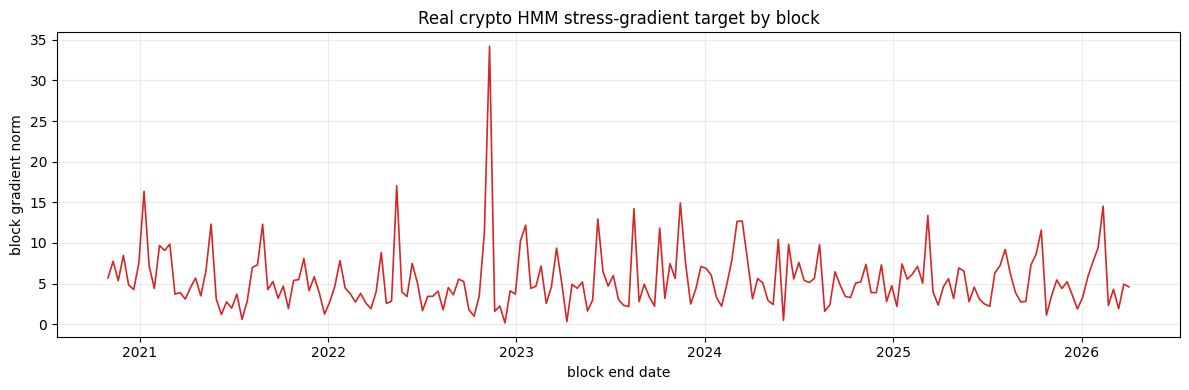

In [7]:
def build_blocks(panel: pd.DataFrame, asset_cols: list[str], L: int = 10) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray]:
    y = panel[asset_cols].to_numpy(dtype=float)
    q = panel["stress_prob"].to_numpy(dtype=float)
    dates = panel["date"].to_numpy()

    n_blocks = len(panel) // L
    y = y[: n_blocks * L]
    q = q[: n_blocks * L]
    dates = dates[: n_blocks * L]

    # Stress-state moment estimates used as the current HMM parameter value.
    q_sum = np.maximum(q.sum(), 1e-8)
    mu = (q[:, None] * y).sum(axis=0) / q_sum
    var = (q[:, None] * (y - mu[None, :]) ** 2).sum(axis=0) / q_sum
    sigma = np.sqrt(np.maximum(var, 1e-5))

    rows = []
    feature_rows = []
    grad_vectors = []

    for b in range(n_blocks):
        lo, hi = b * L, (b + 1) * L
        Yb = y[lo:hi]
        qb = q[lo:hi]
        centered = Yb - mu[None, :]

        g_mu = (qb[:, None] * centered / sigma[None, :] ** 2).sum(axis=0)
        g_logsigma = (qb[:, None] * (-1.0 + centered**2 / sigma[None, :] ** 2)).sum(axis=0)
        g = np.concatenate([g_mu, g_logsigma])
        grad_vectors.append(g)

        abs_y = np.abs(Yb)
        sq_y = Yb**2
        downside = np.maximum(-Yb, 0.0)

        feats = {
            "block": b,
            "start_date": pd.Timestamp(dates[lo]),
            "end_date": pd.Timestamp(dates[hi - 1]),
            "stress_prob_mean": float(qb.mean()),
            "stress_prob_max": float(qb.max()),
            "stress_days_soft": float(qb.sum()),
            "market_abs": float(abs_y.mean()),
            "market_sq": float(sq_y.mean()),
            "dispersion": float(np.std(Yb, axis=1).mean()),
            "tail_count": float((abs_y > 1.5).sum()),
            "downside_market": float(downside.mean()),
        }

        for name, j in zip(asset_names, range(len(asset_cols))):
            feats[f"{name}_abs"] = float(abs_y[:, j].mean())
            feats[f"{name}_sq"] = float(sq_y[:, j].mean())
            feats[f"{name}_downside"] = float(downside[:, j].mean())

        feature_rows.append(feats)
        rows.append({
            "block": b,
            "start_date": pd.Timestamp(dates[lo]),
            "end_date": pd.Timestamp(dates[hi - 1]),
            "stress_prob_mean": float(qb.mean()),
            "stress_days_soft": float(qb.sum()),
            "grad_norm": float(np.linalg.norm(g)),
        })

    block_df = pd.DataFrame(rows)
    feature_df = pd.DataFrame(feature_rows)
    grad_matrix = np.vstack(grad_vectors)
    return block_df, feature_df, grad_matrix


L_BLOCK = 10
block_df, feature_df, G_blocks = build_blocks(panel, asset_cols, L=L_BLOCK)
feature_cols = [
    c
    for c in feature_df.columns
    if c not in {"block", "start_date", "end_date", "stress_prob_mean", "stress_prob_max", "stress_days_soft"}
]

grad_norm = block_df["grad_norm"].to_numpy()
grad_cv = float(np.std(grad_norm) / np.mean(grad_norm))

print("n blocks:", len(block_df))
print("block length:", L_BLOCK)
print("gradient norm CV:", round(grad_cv, 3))
display(block_df.head())
display(feature_df[["block", "start_date", "end_date", "market_abs", "market_sq", "dispersion", "tail_count", "downside_market"]].head())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(block_df["end_date"], grad_norm, lw=1.2, color="tab:red")
ax.set_title("Real crypto HMM stress-gradient target by block")
ax.set_ylabel("block gradient norm")
ax.set_xlabel("block end date")
plt.tight_layout()
plt.show()

## 3. Sampling and online-learning utilities

For a window of candidate blocks, each method defines probabilities \(a_b\). We estimate the full window gradient with

\[
\widehat G=\frac{1}{M}\sum_{m=1}^M\frac{G_{J_m}}{a_{J_m}},
\qquad J_m\sim a.
\]

This is unbiased for the full block-gradient sum up to the fixed \(1/M\) convention used across methods. Lower RMSE means a better stochastic-gradient estimator for the same number of sampled blocks.

The static TASS-like rule trains a fixed feature model early and never updates. The online rule starts from the same model but updates with sampled block feedback using discounted ridge regression.

In [10]:
def standardize_train_apply(X_train: np.ndarray, X_all: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std = np.where(std < 1e-8, 1.0, std)
    return (X_train - mean) / std, (X_all - mean) / std, mean, std


def ridge_fit(X: np.ndarray, y: np.ndarray, ridge: float = 5.0, weights: np.ndarray | None = None) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    X1 = np.column_stack([np.ones(len(X)), X])
    if weights is None:
        W = np.ones(len(X))
    else:
        W = np.asarray(weights, dtype=float)
        W = W / max(np.mean(W), 1e-8)
    Xw = X1 * np.sqrt(W)[:, None]
    yw = y * np.sqrt(W)
    penalty = ridge * np.eye(X1.shape[1])
    penalty[0, 0] = 0.0
    return np.linalg.solve(Xw.T @ Xw + penalty, Xw.T @ yw)


def predict(beta: np.ndarray, X: np.ndarray) -> np.ndarray:
    return np.column_stack([np.ones(len(X)), X]) @ beta


def probs_from_scores(scores: np.ndarray, floor: float = 0.05, temp: float = 1.0) -> np.ndarray:
    scores = np.asarray(scores, dtype=float)
    scores = scores - np.max(scores)
    raw = np.exp(scores / max(temp, 1e-6))
    raw = raw / raw.sum()
    n = len(raw)
    return (1.0 - floor) * raw + floor * np.ones(n) / n


def estimator_rmse(G_window: np.ndarray, probs: np.ndarray, M: int = 6, n_rep: int = 120, seed: int = 0) -> float:
    local_rng = np.random.default_rng(seed)
    n = len(probs)
    true_sum = G_window.sum(axis=0)
    errs = []
    for _ in range(n_rep):
        idx = local_rng.choice(n, size=M, replace=True, p=probs)
        est = (G_window[idx] / probs[idx, None]).mean(axis=0)
        errs.append(np.linalg.norm(est - true_sum))
    return float(np.sqrt(np.mean(np.square(errs))))


def top_decile_mass(probs: np.ndarray, true_scores: np.ndarray) -> float:
    n_top = max(1, int(np.ceil(0.10 * len(probs))))
    idx = np.argsort(true_scores)[-n_top:]
    return float(probs[idx].sum())

## 4. Run the real-data comparison

The setup intentionally makes online adaptation relevant:

- `static_tass` trains on the first 30 blocks and freezes;
- `online` starts from the same initial fit;
- each round considers the most recent 50 blocks;
- online receives noisy feedback from the blocks it sampled and refits with exponential discounting.

This approximates the real workflow: a fixed TASS precomputation can become stale as the market changes, while the online sampler keeps learning which visible block features currently predict high HMM gradient contribution.

In [13]:
WINDOW = 50
TRAIN_BLOCKS = 30
M_BLOCKS = 6
ONLINE_UPDATE_BLOCKS = 18
N_REP_RMSE = 120

RIDGE = 5.0
DISCOUNT = 0.93
OBS_NOISE_SD = 0.05

STATIC_FLOOR = 0.05
STATIC_TEMP = 0.90
ONLINE_FLOOR = 0.08
ONLINE_TEMP = 1.00
ORACLE_FLOOR = 0.02
ORACLE_TEMP = 0.80

X_raw = feature_df[feature_cols].to_numpy(dtype=float)
y_target = np.log(block_df["grad_norm"].to_numpy() + 1e-8)

X_train_std, X_std, x_mean, x_std = standardize_train_apply(X_raw[:TRAIN_BLOCKS], X_raw)
beta_static = ridge_fit(X_std[:TRAIN_BLOCKS], y_target[:TRAIN_BLOCKS], ridge=RIDGE)
beta_online = beta_static.copy()

observed_x = [X_std[i] for i in range(TRAIN_BLOCKS)]
observed_y = [y_target[i] for i in range(TRAIN_BLOCKS)]
observed_t = [i for i in range(TRAIN_BLOCKS)]

records = []
coef_records = []
seed_offsets = {
    "uniform": 101,
    "static_tass": 202,
    "online": 303,
    "oracle": 404,
}

round_id = 0
for end in range(WINDOW, len(block_df) + 1):
    start = end - WINDOW
    idx_window = np.arange(start, end)
    Xw = X_std[idx_window]
    Gw = G_blocks[idx_window]
    true_norm = block_df.loc[idx_window, "grad_norm"].to_numpy()

    p_uniform = np.ones(WINDOW) / WINDOW
    p_static = probs_from_scores(predict(beta_static, Xw), floor=STATIC_FLOOR, temp=STATIC_TEMP)
    p_online = probs_from_scores(predict(beta_online, Xw), floor=ONLINE_FLOOR, temp=ONLINE_TEMP)
    p_oracle = probs_from_scores(np.log(true_norm + 1e-8), floor=ORACLE_FLOOR, temp=ORACLE_TEMP)

    probs_by_method = {
        "uniform": p_uniform,
        "static_tass": p_static,
        "online": p_online,
        "oracle": p_oracle,
    }

    for method, probs in probs_by_method.items():
        rmse = estimator_rmse(
            Gw,
            probs,
            M=M_BLOCKS,
            n_rep=N_REP_RMSE,
            seed=RNG_SEED + 10_000 * round_id + seed_offsets[method],
        )
        records.append({
            "round": round_id,
            "window_start_block": int(start),
            "window_end_block": int(end - 1),
            "window_start_date": block_df.loc[start, "start_date"],
            "window_end_date": block_df.loc[end - 1, "end_date"],
            "method": method,
            "rmse": rmse,
            "top_decile_mass": top_decile_mass(probs, true_norm),
            "mean_prob_highest_10pct": top_decile_mass(probs, true_norm),
        })

    # The online model only observes feedback from sampled blocks, not the full target.
    sampled_local = rng.choice(WINDOW, size=ONLINE_UPDATE_BLOCKS, replace=True, p=p_online)
    sampled_global = idx_window[sampled_local]
    noisy_feedback = y_target[sampled_global] + rng.normal(0.0, OBS_NOISE_SD, size=ONLINE_UPDATE_BLOCKS)
    for gi, yi in zip(sampled_global, noisy_feedback):
        observed_x.append(X_std[gi])
        observed_y.append(float(yi))
        observed_t.append(round_id)

    obs_X = np.vstack(observed_x)
    obs_y = np.asarray(observed_y)
    obs_t = np.asarray(observed_t)
    weights = DISCOUNT ** (round_id - obs_t)
    beta_online = ridge_fit(obs_X, obs_y, ridge=RIDGE, weights=weights)

    coef_row = {
        "round": round_id,
        "window_end_date": block_df.loc[end - 1, "end_date"],
        "intercept": beta_online[0],
    }
    for name, value in zip(feature_cols, beta_online[1:]):
        coef_row[name] = value
    coef_records.append(coef_row)

    round_id += 1

results_df = pd.DataFrame(records)
coef_df = pd.DataFrame(coef_records)

results_df.to_csv(OUT_DIR / "real_crypto_online_weighting_results.csv", index=False)
coef_df.to_csv(OUT_DIR / "real_crypto_online_weighting_coefficients.csv", index=False)
block_df.to_csv(OUT_DIR / "real_crypto_block_gradient_targets.csv", index=False)
feature_df.to_csv(OUT_DIR / "real_crypto_block_features.csv", index=False)

display(results_df.head())
print("rounds:", results_df["round"].nunique())
print("saved:", OUT_DIR)

,round,window_start_block,window_end_block,window_start_date,window_end_date,method,rmse,top_decile_mass,mean_prob_highest_10pct
0,0,0,49,2020-10-22 00:00:00+00:00,2022-03-05 00:00:00+00:00,uniform,122.196076,0.100000,0.100000
1,0,0,49,2020-10-22 00:00:00+00:00,2022-03-05 00:00:00+00:00,static_tass,115.127660,0.227454,0.227454
2,0,0,49,2020-10-22 00:00:00+00:00,2022-03-05 00:00:00+00:00,online,113.335175,0.207886,0.207886
3,0,0,49,2020-10-22 00:00:00+00:00,2022-03-05 00:00:00+00:00,oracle,111.515705,0.260810,0.260810
4,1,1,50,2020-11-01 00:00:00+00:00,2022-03-15 00:00:00+00:00,uniform,119.850763,0.100000,0.100000


rounds: 150
saved: /Users/diego/Stat 221/crypto_stage1_processed/real_crypto_online_weighting_benchmark


## 5. Summarize estimator quality

Lower RMSE is better. `oracle` is included as a ceiling: it uses the actual block gradient norms to sample and is not available in practice.

The key comparisons are:

- online versus uniform: does feature-informed weighting help?
- online versus static TASS: does online updating help after the static rule becomes stale?

In [15]:
summary = (
    results_df.groupby("method")
    .agg(
        mean_rmse=("rmse", "mean"),
        median_rmse=("rmse", "median"),
        mean_top_decile_mass=("top_decile_mass", "mean"),
    )
    .sort_values("mean_rmse")
    .reset_index()
)

wide = results_df.pivot_table(index="round", columns="method", values="rmse")
late_start = int(0.55 * len(wide))
late = wide.iloc[late_start:]

improvement_rows = []
for baseline in ["uniform", "static_tass", "oracle"]:
    improvement_rows.append({
        "comparison": f"online_vs_{baseline}",
        "overall_pct_rmse_reduction": 100.0 * (wide[baseline].mean() - wide["online"].mean()) / wide[baseline].mean(),
        "late_pct_rmse_reduction": 100.0 * (late[baseline].mean() - late["online"].mean()) / late[baseline].mean(),
    })

improvement_df = pd.DataFrame(improvement_rows)

summary.to_csv(OUT_DIR / "real_crypto_online_weighting_summary.csv", index=False)
improvement_df.to_csv(OUT_DIR / "real_crypto_online_weighting_improvement.csv", index=False)

display(summary)
display(improvement_df)

,method,mean_rmse,median_rmse,mean_top_decile_mass
0,oracle,109.625560,109.920012,0.304472
1,online,113.814416,113.535731,0.232204
2,static_tass,117.385302,115.977231,0.246343
3,uniform,132.986084,133.419919,0.100000


,comparison,overall_pct_rmse_reduction,late_pct_rmse_reduction
0,online_vs_uniform,14.416296,8.334025
1,online_vs_static_tass,3.042021,3.673179
2,online_vs_oracle,-3.821058,-3.135363


## 6. Visual diagnostics

The first plot shows estimator RMSE through time. If online weighting is doing its job, its curve should generally sit below uniform and often below static TASS after the early training regime.

The second plot shows how much sampling probability each method assigns to the highest-gradient 10% of blocks in the current window. This is the intuitive “are we spending computation where the gradient action is?” diagnostic.

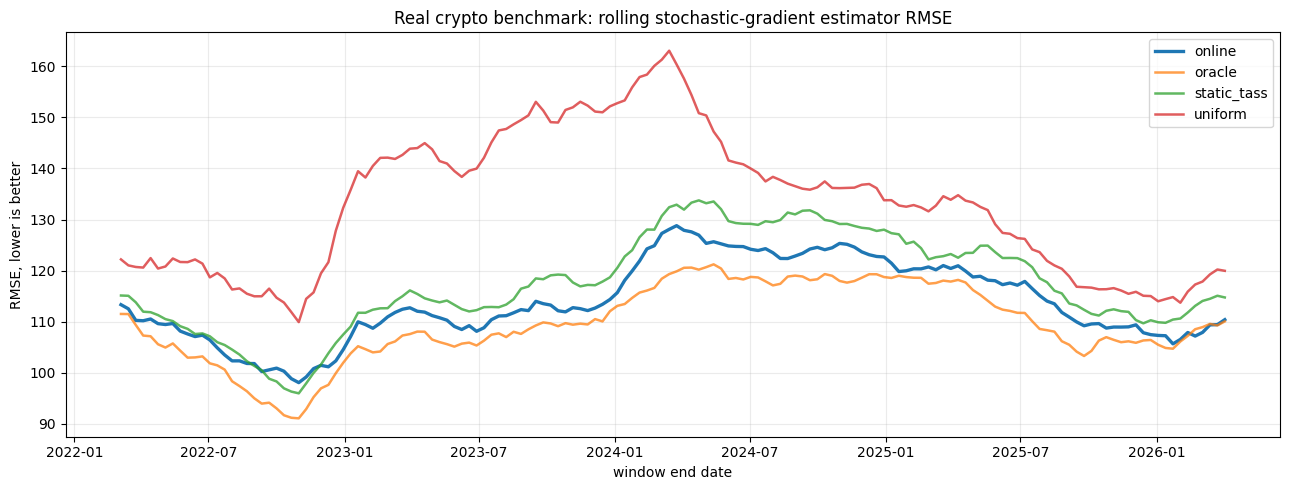

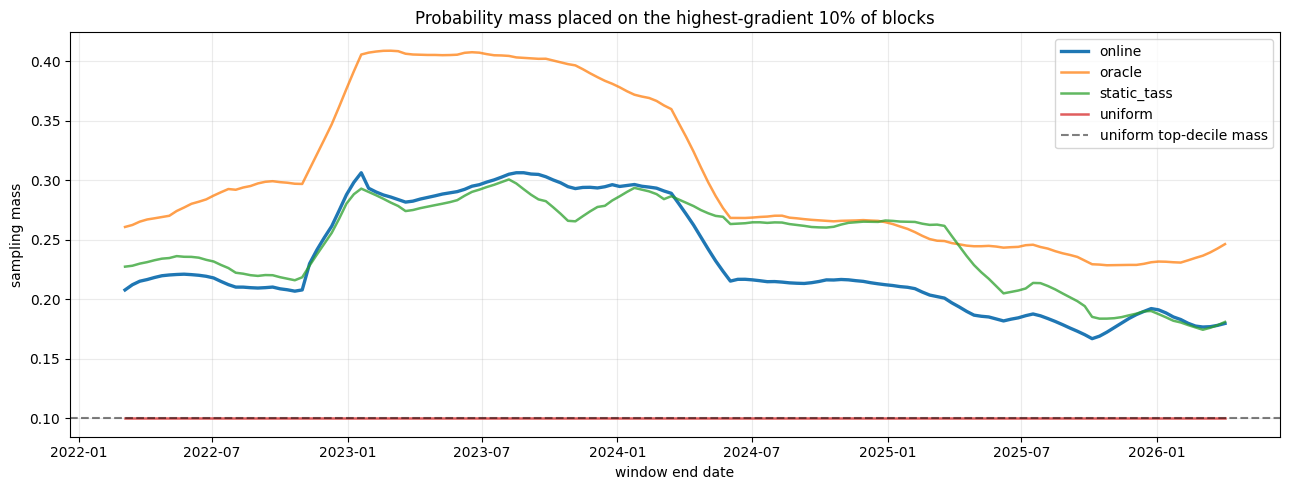

In [17]:
plot_df = results_df.copy()
plot_df["window_end_date"] = pd.to_datetime(plot_df["window_end_date"], utc=True)
plot_df = plot_df.sort_values(["method", "round"])

fig, ax = plt.subplots(figsize=(13, 5))
for method, g in plot_df.groupby("method"):
    s = g.set_index("window_end_date")["rmse"].rolling(8, min_periods=1).mean()
    lw = 2.4 if method == "online" else 1.8
    alpha = 1.0 if method == "online" else 0.75
    ax.plot(s.index, s.values, label=method, lw=lw, alpha=alpha)
ax.set_title("Real crypto benchmark: rolling stochastic-gradient estimator RMSE")
ax.set_ylabel("RMSE, lower is better")
ax.set_xlabel("window end date")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "real_crypto_rmse_over_time.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(13, 5))
for method, g in plot_df.groupby("method"):
    s = g.set_index("window_end_date")["top_decile_mass"].rolling(8, min_periods=1).mean()
    lw = 2.4 if method == "online" else 1.8
    alpha = 1.0 if method == "online" else 0.75
    ax.plot(s.index, s.values, label=method, lw=lw, alpha=alpha)
ax.axhline(0.10, color="black", linestyle="--", alpha=0.5, label="uniform top-decile mass")
ax.set_title("Probability mass placed on the highest-gradient 10% of blocks")
ax.set_ylabel("sampling mass")
ax.set_xlabel("window end date")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "real_crypto_top_decile_mass.png", dpi=180)
plt.show()

## 7. What did the online model learn?

This plot tracks a few interpretable online coefficients over time. A coefficient moving around is not bad here. It is the point: the mapping from visible market features to high-gradient stress blocks is allowed to drift.

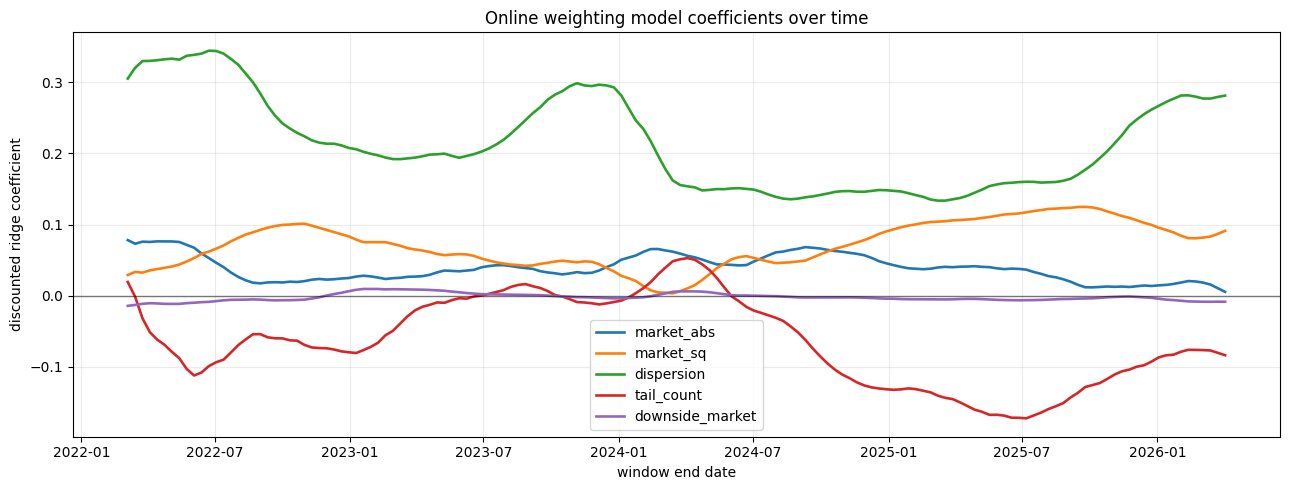

In [22]:
coef_plot_cols = [
    "market_abs",
    "market_sq",
    "dispersion",
    "tail_count",
    "downside_market",
]
coef_plot_cols = [c for c in coef_plot_cols if c in coef_df.columns]

fig, ax = plt.subplots(figsize=(13, 5))
for col in coef_plot_cols:
    s = coef_df.set_index(pd.to_datetime(coef_df["window_end_date"], utc=True))[col].rolling(8, min_periods=1).mean()
    ax.plot(s.index, s.values, label=col, lw=1.9)
ax.axhline(0.0, color="black", lw=1, alpha=0.5)
ax.set_title("Online weighting model coefficients over time")
ax.set_ylabel("discounted ridge coefficient")
ax.set_xlabel("window end date")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "real_crypto_online_coefficients.png", dpi=180)
plt.show()

## 8. Interpretation

This real-data benchmark is deliberately modest and honest. It does not claim that online weighting fixes full-chain HMM mixing by itself. Instead, it tests the mechanism that our method needs:

- high-gradient blocks are heterogeneous;
- their importance is partially predictable from cheap block features;
- the feature-to-importance map drifts over calendar time;
- online weighting adapts better than a frozen static rule.

That is the real-world analogue of the proposed next-step benchmark: streaming crypto stress regimes, where yesterday's targeted subsampling rule can become today's compute leak.